# **Evaluación 1 - Machine Learning**


## **Sección 1**

Genere las siguientes imágenes de manera sintética. \\

**NOTA:** NO USE FUNCIONES ESPECIALES DE LIBRERÍAS DE PROCESAMIENTO DE IMÁGENES (CV, PIL, SKIMAGE) MÁS QUE PARA CARGARLAS O GUARDARLAS. USE SÓLO NUMPY Y OPERACIONES CON ARREGLOS

In [ ]:
# Import some libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt
import imageio
from google.colab.patches import cv2_imshow

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

### **Ejercicio 1 (C = 0.7)**

Genere la siguiente imagen [resultado](https://drive.google.com/file/d/1Z3yNgkQVFJyaCRyTzkjFhIB_3kxqs61q/view?usp=drive_link). \\
**NOTA:** En la salida de la celda puede encontrar el tamaño de la imagen final.

Dimensiones de la matriz: (400, 600)


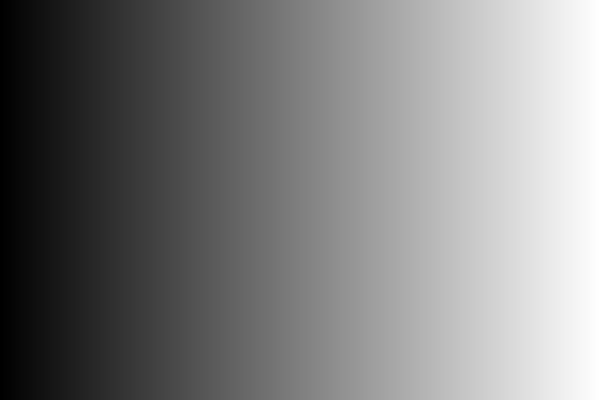

In [ ]:

alto = 400
ancho = 600

fila_degradado = np.linspace(0, 255, ancho, dtype=np.uint8)

imagen_matriz = np.tile(fila_degradado, (alto, 1))

print("Dimensiones de la matriz:", imagen_matriz.shape)

cv2_imshow(imagen_matriz)

### **Ejercicio 2 (C = 1.0)**

Genere la siguiente imagen [resultado](https://drive.google.com/file/d/13z0tvGYD-37_PuHOqoRWHGGmGq7xxvU7/view?usp=drive_link).

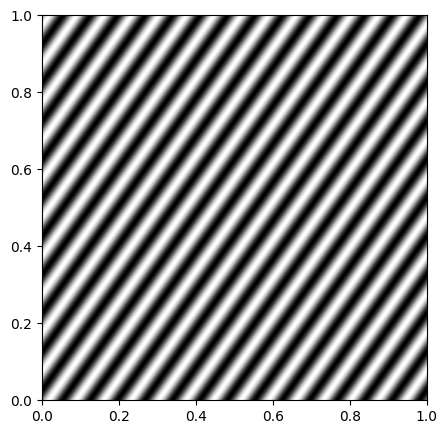

In [ ]:

resolucion = 500

x = np.linspace(0, 1, resolucion)
y = np.linspace(0, 1, resolucion)

X, Y = np.meshgrid(x, y)

frecuencia_x = 14
frecuencia_y = -10

onda = np.sin(2 * np.pi * (frecuencia_x * X + frecuencia_y * Y))

imagen_matriz = ((onda + 1) / 2 * 255).astype(np.uint8)

plt.figure(figsize=(5, 5))

plt.imshow(imagen_matriz, cmap='gray', extent=[0, 1, 0, 1], origin='lower')
plt.show()

## **Sección 2**

Genere las siguientes imágenes usando recorridos por píxeles a partir de [lena.jpg](https://drive.google.com/file/d/1gH5sJN__2g7f9ndLhLvTECdOBJIGUbg_/view?usp=sharing)  y [bengal_tiger.jpg](https://drive.google.com/file/d/1oz8CWUjN7UBNJNq1XOxqzwmYcJRTRmxr/view?usp=sharing)

**NOTA:** NO USE FUNCIONES ESPECIALES DE LIBRERÍAS DE PROCESAMIENTO DE IMÁGENES (CV, PIL, SKIMAGE) MÁS QUE PARA CARGARLAS O GUARDARLAS. USE SÓLO NUMPY Y OPERACIONES CON ARREGLOS

### **Ejercicio 3 (C = 1.6)**

Genere la siguiente animación [resultado](https://drive.google.com/file/d/1jSNhV2CYdm6-E5wuo7o5wE-b2J-_mEil/view?usp=drive_link).

In [1]:


lena  = cv2.imread('lena.jpg')
lena  = cv2.cvtColor(lena, cv2.COLOR_BGR2RGB)
tiger = cv2.imread('tiger.jpg')
tiger = cv2.cvtColor(tiger, cv2.COLOR_BGR2RGB)

h = min(lena.shape[0], tiger.shape[0])
w = min(lena.shape[1], tiger.shape[1])
lena_c  = lena[:h, :w]
tiger_c = tiger[:h, :w]


n_frames = 20
frames   = []
lena_f   = lena_c.astype(np.float64)
tiger_f  = tiger_c.astype(np.float64)

for i in range(n_frames):
    t     = i / (n_frames - 1)          # 0.0 → 1.0
    frame = ((1.0 - t) * lena_f + t * tiger_f).astype(np.uint8)
    frames.append(frame)


imageio.mimsave('ejercicio3.gif', frames, duration=0.15, loop=0)

### **Ejercicio 4 (C = 1.0)**

Genere la siguiente imagen [resultado](https://drive.google.com/file/d/1UX2Y8Q2xWy5ej0hl_r1B-fKAQ8SX5DI1/view?usp=drive_link).

In [ ]:


lena = cv2.imread('lena.jpg')
lena = cv2.cvtColor(lena, cv2.COLOR_BGR2RGB)

final_h, final_w = 300, 400
half_h = final_h // 2  # 150


row_idx = np.linspace(0, lena.shape[0] - 1, half_h).astype(int)
col_idx = np.linspace(0, lena.shape[1] - 1, final_w).astype(int)
lena_scaled = lena[np.ix_(row_idx, col_idx)]


lena_flipped = lena_scaled[::-1, :, :]


resultado = np.vstack([lena_scaled, lena_flipped])

cv2.imwrite('ejercicio4.png', cv2.cvtColor(resultado, cv2.COLOR_RGB2BGR))

### **Ejercicio 5 (C = 0.7)**

Genere la siguiente imagen [resultado](https://drive.google.com/file/d/10jxoa_muSn6bxsDBy7Vw88wz1oirMiRH/view?usp=drive_link)

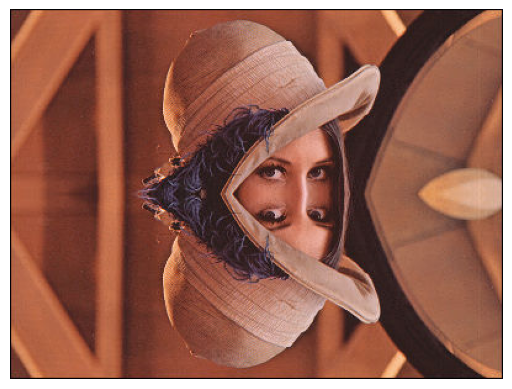

In [ ]:


lena = cv2.imread('lena.jpg')
lena = cv2.cvtColor(lena, cv2.COLOR_BGR2RGB)


final_h, final_w = 300, 400
row_idx = np.linspace(0, lena.shape[0]-1, final_h).astype(int)
col_idx = np.linspace(0, lena.shape[1]-1, final_w).astype(int)
lena_scaled = lena[np.ix_(row_idx, col_idx)]


cell_h, cell_w = final_h // 4, final_w // 5
colors_cycle   = np.array([[255,0,0], [0,255,0], [0,0,255]])

tablero = np.zeros((final_h, final_w, 3), dtype=np.float64)
for r in range(4):
    for c in range(5):
        color = colors_cycle[(r + c) % 3]
        tablero[r*cell_h:(r+1)*cell_h,
                c*cell_w:(c+1)*cell_w] = color


resultado = np.clip(lena_scaled.astype(np.float64) + tablero, 0, 255).astype(np.uint8)


cv2.imwrite('ejercicio5.png', cv2.cvtColor(resultado, cv2.COLOR_RGB2BGR))